***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [第1章：利用干涉阵开展射电科学](1_0_introduction.ipynb)  
    * 上一节：[1.2 电磁辐射与天文测量量](1_2_electromagnetic_radiation_and_astronomical_quantities.ipynb)
    * 下一节：[1.4 射电波段](1_4_radio_regime.ipynb)

***


导入标准模块:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML 
HTML('../style/course.css') #apply general CSS

导入本节所需的专用模块:

In [1]:
from IPython.display import Image

## 1.3 辐射传输<a id='science:sec:radiative_transport'></a>

上一节已经指出，在没有新的发射和吸收时，比强度 $I_\nu$ 沿射线保持不变。现实中的天体环境显然很少这么理想。电离气体会吸收、分子云会发射和吸收谱线、尘埃与等离子体会重新分配辐射能量，因此观测者真正收到的信号，往往不是源在“起点处”的原始亮度，而是经过介质处理后的结果。辐射传输方程正是把这种变化写成定量关系的基本工具。

对于射电天文学来说，辐射传输并不是独立于观测技术的纯理论话题。无论是理解 H II 区的自由-自由连续谱、H I 21 cm 的发射和吸收、分子谱线的自吸收，还是理解为什么亮温能近似等于气体温度，都离不开这一节的语言。后续关于热辐射、谱线辐射和定量解释图像亮度的很多内容，都会反复用到这里的概念。

本节要建立三层理解。第一，辐射传输方程中的每一项都对应明确的物理过程；第二，光学深度提供了判断光学薄、过渡和光学厚状态的自然尺度；第三，发射和吸收并不是两类彼此孤立的现象，而是同一条传输方程在不同源函数和背景条件下的表现。这些概念会在后面的热辐射、谱线辐射和图像解释中反复出现。


### 1.3.1 局部平衡：一束辐射在介质中会发生什么

设一束频率为 $\nu$ 的辐射沿路径坐标 $s$ 传播。穿过一小段路径 $ds$ 时，强度的变化可以分成两类局部过程。第一类是吸收：介质从原有射线中移走一部分辐射，移走的量与当前强度成正比；当前射线越亮，同一段介质能够吸收掉的功率也越多。第二类是发射：介质自身向这条射线方向加入新的辐射，这一项由介质的局部温度、粒子分布、跃迁概率等物理状态决定，不需要依赖入射射线已经有多亮。

在线性近似下，辐射传输方程写成

<a id='science:eq:03_001'></a>

$$\frac{dI_\nu}{ds} = -\kappa_\nu I_\nu + \varepsilon_\nu$$

其中 $\kappa_\nu$ 是吸收系数，描述单位路径长度内辐射被削弱的程度；$\varepsilon_\nu$ 是发射系数，描述介质沿该方向每单位路径长度新增的辐射。这个方程的价值在于，它把微观物理过程压缩成了两个局地系数，然后直接连接到我们最终观测的比强度。

从量纲上看，$\kappa_\nu$ 的单位是长度的倒数，例如 $\mathrm{m}^{-1}$；它越大，同样几何厚度的介质越不透明。$\varepsilon_\nu$ 的单位则相当于“比强度每单位长度的增量”。实际天体中的 $\kappa_\nu$ 和 $\varepsilon_\nu$ 由不同微观机制决定，例如自由-自由吸收、同步自吸收、原子或分子跃迁吸收，以及相应的热辐射或谱线发射。教材层面先不急着代入每一种机制的详细公式，重要的是先看清：吸收项依赖当前的 $I_\nu$，发射项不依赖当前射线已经有多亮。


如果只保留发射项，即 $\kappa_\nu=0$，沿路径只会不断积累新辐射，最终强度等于边界强度加上所有局地发射的积分。如果只保留吸收项，即 $\varepsilon_\nu=0$，方程变成 $dI_\nu/ds=-\kappa_\nu I_\nu$，解为指数衰减。因此，在辐射传输里“指数衰减”并不是一个额外假设，而是吸收量与当前强度成正比这一局部关系的直接后果。


### 1.3.2 光学深度：比几何长度更有用的路径坐标

虽然上式可以直接用几何长度 $s$ 求解，但在天体物理里更自然的变量是**光学深度** $\tau_\nu$。我们定义

<a id='science:eq:03_002'></a>

$$d\tau_\nu \equiv \kappa_\nu\,ds$$

它描述的不是“走了多远”，而是“沿途一共经历了多少吸收”。因此，$\tau_\nu$ 更像一个无量纲的不透明度尺度。当 $\tau_\nu\ll1$ 时，介质在该频率上光学薄，大部分背景辐射可以直接穿过，介质自身发射也只贡献一小部分修正；当 $\tau_\nu\gg1$ 时，介质光学厚，远端背景几乎被完全重处理，观测者主要看到靠近前表面的源函数。

把传输方程改写到光学深度变量上，并引入**源函数**

<a id='science:eq:03_003'></a>

$$S_\nu \equiv \frac{\varepsilon_\nu}{\kappa_\nu}$$

后，就得到更紧凑的形式：

<a id='science:eq:03_004'></a>

$$\frac{dI_\nu}{d\tau_\nu} = -I_\nu + S_\nu$$

这一写法在教学上非常重要，因为它把所有局部物理压缩成一个源函数 $S_\nu$。此后我们真正需要关心的，就是这个介质倾向于把辐射“拉向”什么样的亮度水平。


从物理直觉上说，源函数不是一个抽象代数比值，而是介质本身“想要建立起来”的特征亮度。将传输方程写成 $dI_\nu/d\tau_\nu=-(I_\nu-S_\nu)$ 可以看出，$S_\nu$ 是这个一阶方程的平衡值。若当前射线强度 $I_\nu$ 小于 $S_\nu$，介质的净效应是让它变亮；若 $I_\nu$ 大于 $S_\nu$，吸收更占优势，射线会变暗。正是这个简单判断，控制了吸收线与发射线、前景云与背景连续谱之间的关系。


下图给出了辐射沿视线传播时，背景、吸收和介质自身发射之间关系的示意。


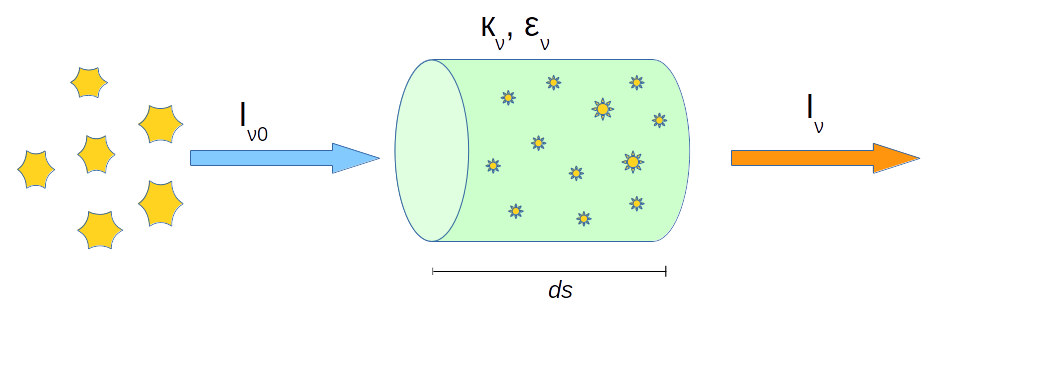

In [3]:
Image(filename='figures/radiative_transport.png', width=800)

**图 1.3.1**：沿视线的辐射传输示意。背景辐射在穿过前景介质时被吸收，同时介质自身又向视线方向发射新的辐射；观测者最终接收到的是背景剩余项和介质发射项的叠加。


### 1.3.3 形式解：观测者最终看到什么

对上式使用积分因子法，可以得到辐射传输的形式解。若观测者位于光学深度为 $0$ 的一端，沿视线向源内部积分到总光学深度 $\tau_\nu$，则观测到的强度为

<a id='science:eq:03_005'></a>

$$I_\nu(0) = I_{\nu,\mathrm{bg}}\,e^{-\tau_\nu} + \int_0^{\tau_\nu} S_\nu(t)e^{-t}\,dt$$

这里 $I_{\nu,\mathrm{bg}}$ 表示最远端背景在进入介质前的强度。第一项 $I_{\nu,\mathrm{bg}}e^{-\tau_\nu}$ 是背景辐射穿过整层介质后留下的部分，指数因子记录了沿途吸收造成的衰减。积分项则把每一层介质的局地发射累加起来；位于更深处的发射还要穿过前方介质，因此会多乘一个 $e^{-t}$ 的吸收权重。

这个形式解之所以重要，是因为几乎所有实际射电问题都可以被归结为对这两个贡献的比较。前景云之所以会显示为吸收，是因为背景太亮；热等离子体之所以表现为发射，是因为其源函数高于背景；而在厚介质中，最深处的背景往往已经完全看不到了。


### 1.3.4 常源函数情形：最值得记住的一条公式

如果一层介质中源函数近似为常数，例如在局部热平衡近似下温度变化不大，那么形式解会大大简化为

<a id='science:eq:03_006'></a>

$$I_\nu^{\mathrm{obs}} = I_{\nu,\mathrm{bg}}e^{-\tau_\nu} + S_\nu\left(1-e^{-\tau_\nu}\right)$$

这是射电天文学中最值得反复回忆的一条公式之一，因为它几乎把所有常见情形都包含进去了。若没有背景源，$I_{\nu,\mathrm{bg}}=0$，观测到的亮度就是介质自身发射逐渐饱和到 $S_\nu$ 的过程。若介质光学薄，$\tau_\nu\ll1$，利用 $e^{-\tau_\nu}\simeq1-\tau_\nu$ 可得

$$I_\nu^{\mathrm{obs}} \approx I_{\nu,\mathrm{bg}} + \tau_\nu(S_\nu-I_{\nu,\mathrm{bg}}).$$

这个近似说明，薄介质只是对背景做一个小修正，修正的符号由 $S_\nu-I_{\nu,\mathrm{bg}}$ 决定。若介质光学厚，$\tau_\nu\gg1$，指数项趋近于零，观测强度趋向 $S_\nu$。这三个极限分别对应射电连续谱和谱线分析中最常见的三种情形：薄层发射、薄层吸收，以及厚介质趋近源函数本身。

这条公式也给出一条很实用的判断：当 $\tau_\nu$ 很小时，观测结果主要是在背景上叠加一个很小的差值项；当 $\tau_\nu$ 很大时，背景记忆被擦掉，观测者主要看到的是介质本身的源函数。很多射电图像中的“亮边”“暗带”“自吸收凹陷”，本质上都是这两个极限之间的空间变化。


下面用归一化的亮温语言做一个最小数值实验。令前景介质的源函数对应 $T=100\,\mathrm{K}$，比较不同背景亮温 $T_{\mathrm{bg}}$ 下，观测亮温如何随光学深度变化。


In [ ]:
Image(filename='figures/radiative_transfer_uniform_layer.png', width=720)


**图 1.3.2**：均匀前景层的亮温随光学深度变化。当前景源函数对应 $T=100\,\mathrm{K}$ 时，暗背景会被前景层增亮，亮背景会被前景层吸收压低；不管背景起点如何，只要 $\tau_\nu$ 足够大，观测亮温都会趋向前景介质自己的温度。这正是“光学厚时只能看到表层”的定量版本。


### 1.3.5 LTE、黑体辐射与亮温语言

在局部热力学平衡（LTE）条件下，基尔霍夫定律给出

<a id='science:eq:03_007'></a>

$$S_\nu = B_\nu(T)$$

也就是说，源函数等于温度为 $T$ 时的普朗克函数。于是上面的常源函数解变为

<a id='science:eq:03_008'></a>

$$I_\nu^{\mathrm{obs}} = I_{\nu,\mathrm{bg}}e^{-\tau_\nu} + B_\nu(T)\left(1-e^{-\tau_\nu}\right)$$

这条公式解释了为什么光学厚热源会趋向黑体辐射，而光学薄热源则只发出黑体的一小部分。对于射电天文学，若再进入瑞利-金斯极限，用亮温表示，就可写成更直观的形式：

<a id='science:eq:03_009'></a>

$$T_b^{\mathrm{obs}} = T_{\mathrm{bg}}e^{-\tau_\nu} + T\left(1-e^{-\tau_\nu}\right)$$

这正是后面理解 H I 自旋温度、H II 区热连续谱和许多吸收/发射线现象时最方便的表达。这一步可以看作“射电语言”的形成过程：一般辐射传输公式被翻译成射电观测可直接使用的亮温与光学深度关系。


### 1.3.6 发射线、吸收线与背景源的关系

从常源函数解立刻可以看出，谱线究竟表现为发射还是吸收，不是由“这是不是一条谱线”单独决定的，而是由源函数与背景强度的相对大小决定的。若 $S_\nu>I_{\nu,\mathrm{bg}}$，前景介质的净效应是增亮，观测上表现为发射；若 $S_\nu<I_{\nu,\mathrm{bg}}$，前景介质会削弱背景，观测上表现为吸收；若二者接近，即使介质真实存在，也可能几乎看不见明显线特征。

这就是为什么同一条 H I 或分子线，在不同背景源和不同几何条件下可以显示为完全不同的观测形态。它也解释了为什么射电谱线工作经常要一边分析谱线本身，一边分析其背后的连续谱背景。


### 1.3.7 为什么这一节对干涉测量也重要

干涉阵虽然测量的是可见度而不是直接的强度沿程变化，但最终恢复出来的仍然是天空亮度分布。因此，只要把图像或数据立方体解释为温度、柱密度、吸收深度或发射强度，就必须回到辐射传输框架。连续谱与谱线为什么会叠加在一起，某些扩展区域为什么是吸收结构而不是“没有信号”，观测到的 $T_b$ 或 Jy/beam 如何转换成物理温度和光学深度约束，以及光学薄近似何时成立、何时失效，这些问题都不能只靠成像算法回答。

也就是说，辐射传输既是天体物理解释工具，也是把图像像素值转成物理量的桥梁。缺少这一节，后面的射电源分类和数据解释就会只剩描述，而很难进入定量分析。


### 1.3.8 本节应记住什么

辐射传输方程把吸收和发射对比强度的局部影响统一写成 $dI_\nu/ds=-\kappa_\nu I_\nu+\varepsilon_\nu$。光学深度 $\tau_\nu$ 是比几何长度更自然的传播变量，它衡量介质在该频率上的不透明程度；源函数 $S_\nu=\varepsilon_\nu/\kappa_\nu$ 则描述介质倾向于把辐射拉向什么亮度水平，量纲与比强度相同。

常源函数解 $I_\nu^{\mathrm{obs}}=I_{\nu,\mathrm{bg}}e^{-\tau_\nu}+S_\nu(1-e^{-\tau_\nu})$ 是本节最重要的工作公式。在 LTE 下有 $S_\nu=B_\nu(T)$，进入射电极限后又可自然转写成亮温形式。发射还是吸收，取决于源函数与背景强度的比较，而不是由“有没有谱线”单独决定。下一节将把这些辐射量和传输语言放回更具体的天文背景中，看看射电波段为什么会揭示出与光学截然不同的天空景象。


***

* 下一节：[1.4 射电波段](1_4_radio_regime.ipynb)
